In [2]:
pip install shap

   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/38.1 MB 2.8 MB/s eta 0:00:14
   - -------------------------------------- 1.6/38.1 MB 2.6 MB/s eta 0:00:14
   -- ------------------------------------- 2.1/38.1 MB 2.7 MB/s eta 0:00:14
   -- ------------------------------------- 2.6/38.1 MB 2.8 MB/s eta 0:00:13
   --- ------------------------------------ 3.1/38.1 MB 2.7 MB/s eta 0:00:13
   --- ------------------------------------ 3.7/38.1 MB 2.7 MB/s eta 0:00:13
   ---- ----------------------------------- 4.5/38.1 MB 2.8 MB/s eta 0:00:13
   ----- ---------------------------------- 5.0/38.1 MB 2.8 MB/s eta 0:00:12
   ------ --------------------------------- 6.0/38.1 MB 3.0 MB/s eta 0:00:11
   ------ --------------------------------- 6.6/38.1 MB 3.0 MB/s eta 0:00:11
   ------- -------------------------------- 7.3/38.1 MB 2.9 MB/s eta 0:00:11
   -------- -

In [22]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import shap

print("✅ Libraries imported!")
print(f"   SHAP version: {shap.__version__}")

✅ Libraries imported!
   SHAP version: 0.52.0


In [23]:
# Load best model
with open('../models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load label encoder
with open('../models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Load symptom columns
with open('../models/symptom_columns.pkl', 'rb') as f:
    symptom_cols = pickle.load(f)

# Load test data
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print("✅ All files loaded!")
print(f"   Model     : Random Forest")
print(f"   Symptoms  : {len(symptom_cols)}")
print(f"   Diseases  : {len(le.classes_)}")
print(f"   Test rows : {X_test.shape[0]}")

✅ All files loaded!
   Model     : Random Forest
   Symptoms  : 131
   Diseases  : 41
   Test rows : 984


In [24]:
print("⏳ Building SHAP explainer (may take 30–60 seconds)...")

# TreeExplainer is optimized for Random Forest
explainer = shap.TreeExplainer(model)

# Use a sample of 100 rows to keep it fast
X_sample = X_test.iloc[:100]

# Calculate SHAP values for the sample
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP explainer built!")
print(f"   SHAP values shape : {np.array(shap_values).shape}")
print(f"   Rows explained    : {X_sample.shape[0]}")
print(f"   Classes           : {len(le.classes_)}")

⏳ Building SHAP explainer (may take 30–60 seconds)...
✅ SHAP explainer built!
   SHAP values shape : (100, 131, 41)
   Rows explained    : 100
   Classes           : 41


In [25]:
# Average absolute SHAP values across all classes and samples
# Shape: (n_classes, n_samples, n_features) → mean over samples & classes
shap_array      = np.array(shap_values)        # (100, 131, 41)
mean_shap       = np.mean(np.abs(shap_array), axis=(0, 2))  # (131,)
print(mean_shap.shape)
assert len(mean_shap) == len(symptom_cols)
# Build importance dataframe
importance_df = pd.DataFrame({
    'symptom'   : symptom_cols,
    'importance': mean_shap
}).sort_values('importance', ascending=False)

print("=== Top 20 Most Important Symptoms (Global) ===\n")
print(importance_df.head(20).to_string(index=False))

print("Samples :", shap_array.shape[0])
print("Features:", shap_array.shape[1])
print("Classes :", shap_array.shape[2])

(131,)
=== Top 20 Most Important Symptoms (Global) ===

          symptom  importance
yellowing_of_eyes    0.002475
           nausea    0.002177
      muscle_pain    0.002113
       chest_pain    0.002020
        diarrhoea    0.001926
   family_history    0.001842
          fatigue    0.001833
          itching    0.001830
       high_fever    0.001754
       dark_urine    0.001700
 loss_of_appetite    0.001640
         vomiting    0.001583
       joint_pain    0.001479
   breathlessness    0.001462
     irritability    0.001422
       mild_fever    0.001346
   yellowish_skin    0.001339
   abdominal_pain    0.001298
           chills    0.001276
altered_sensorium    0.001210
Samples : 100
Features: 131
Classes : 41


In [26]:
print("SHAP array shape:", shap_array.shape)
print("mean_shap shape:", mean_shap.shape)
print("len(symptom_cols):", len(symptom_cols))
print("First 5 symptoms:", symptom_cols[:5])

SHAP array shape: (100, 131, 41)
mean_shap shape: (131,)
len(symptom_cols): 131
First 5 symptoms: ['abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium']


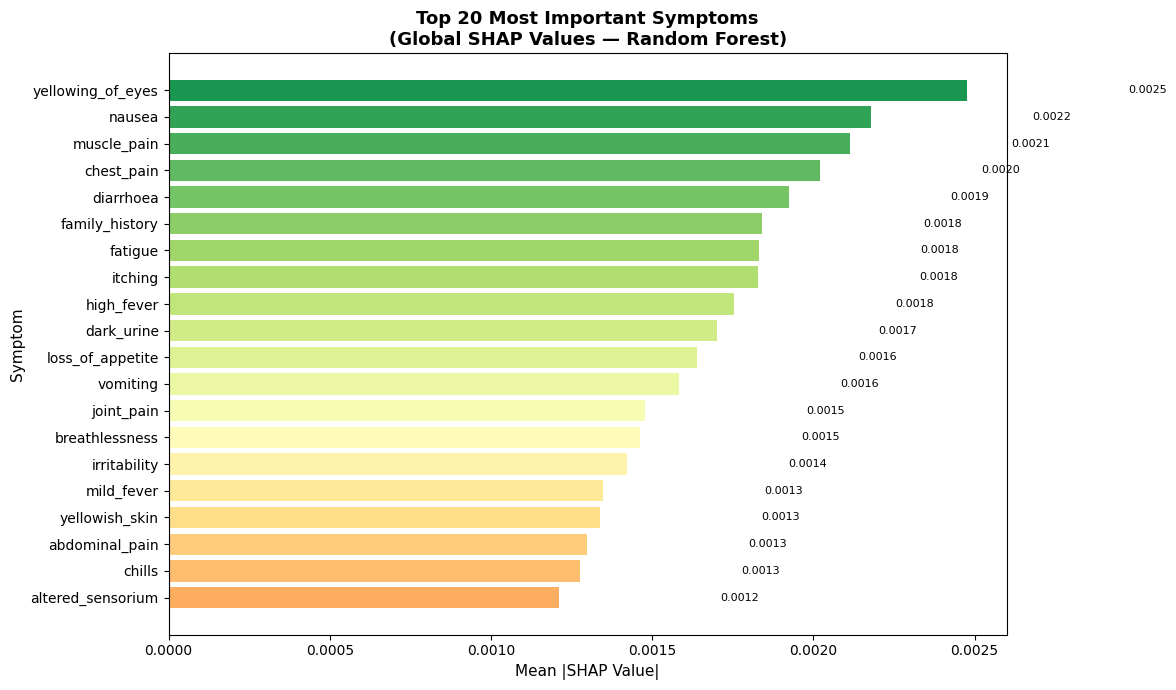

✅ Global importance chart saved!


In [27]:
top20 = importance_df.head(20)

plt.figure(figsize=(12, 7))
bars = plt.barh(
    top20['symptom'][::-1],
    top20['importance'][::-1],
    color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 20))
)

# Add value labels
for bar, val in zip(bars, top20['importance'][::-1]):
    plt.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)

plt.title('Top 20 Most Important Symptoms\n(Global SHAP Values — Random Forest)',
          fontsize=13, fontweight='bold')
plt.xlabel('Mean |SHAP Value|', fontsize=11)
plt.ylabel('Symptom', fontsize=11)
plt.tight_layout()
plt.savefig('../models/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Global importance chart saved!")

In [28]:
# Pick one test sample and explain it
sample_index  = 0
single_sample = X_sample.iloc[[sample_index]]

# Get prediction
predicted_encoded = model.predict(single_sample)[0]
predicted_disease = le.inverse_transform([predicted_encoded])[0]
actual_disease    = le.inverse_transform([y_test.iloc[sample_index]])[0]

print(f"=== Single Prediction Explanation ===")
print(f"   Actual Disease    : {actual_disease}")
print(f"   Predicted Disease : {predicted_disease}")
print(f"   Match             : {'✅ Correct' if actual_disease == predicted_disease else '❌ Wrong'}")

# Get symptoms the patient actually has (value = 1)
active_symptoms = [col for col in symptom_cols 
                   if single_sample[col].values[0] == 1]
print(f"\n   Active symptoms ({len(active_symptoms)}):")
for s in active_symptoms:
    print(f"     • {s}")

=== Single Prediction Explanation ===
   Actual Disease    : Hypertension
   Predicted Disease : Hypertension
   Match             : ✅ Correct

   Active symptoms (4):
     • chest_pain
     • dizziness
     • lack_of_concentration
     • loss_of_balance


In [29]:
# Get SHAP values for this specific prediction
# shap_values[class_index][sample_index] → array of shape (131,)
single_shap = np.array(shap_values)[sample_index, :, predicted_encoded]

# Build per-symptom SHAP dataframe (only active symptoms)
shap_df = pd.DataFrame({
    'symptom'   : symptom_cols,
    'shap_value': single_shap,
    'active'    : single_sample.values[0]
})

# Filter to symptoms that are active AND have non-zero SHAP
shap_df = shap_df[shap_df['active'] == 1].copy()
shap_df = shap_df.sort_values('shap_value', ascending=False)

print(f"=== SHAP Contributions for: {predicted_disease} ===\n")
print(shap_df[['symptom', 'shap_value']].to_string(index=False))

=== SHAP Contributions for: Hypertension ===

              symptom  shap_value
lack_of_concentration    0.297338
            dizziness    0.062920
           chest_pain    0.055652
      loss_of_balance    0.053644


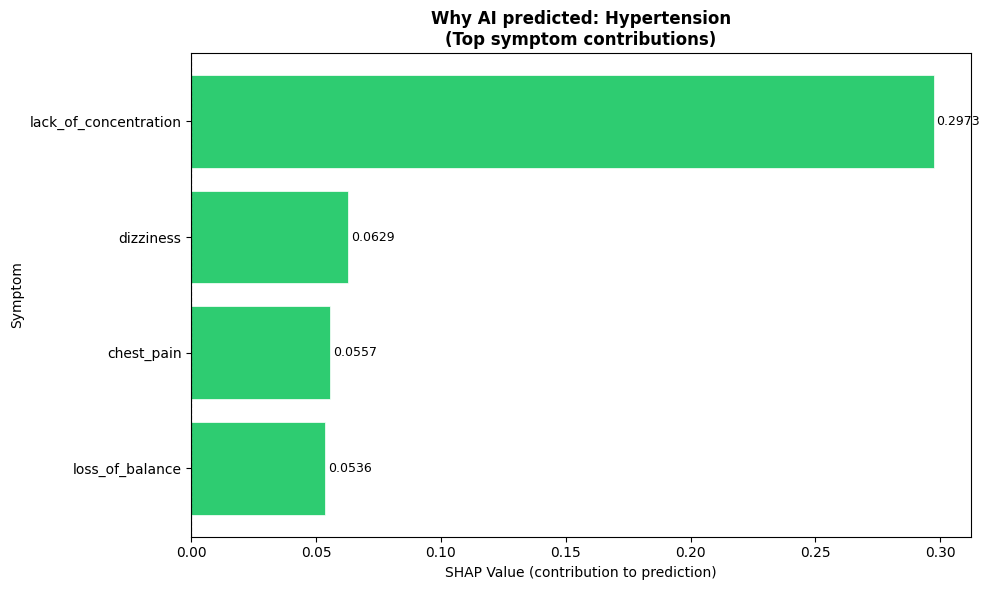

✅ Single prediction chart saved!


In [30]:
# This is the chart that will appear in your React frontend later!
top_symptoms = shap_df.head(10)

colors = ['#2ecc71' if v > 0 else '#e74c3c' 
          for v in top_symptoms['shap_value']]

plt.figure(figsize=(10, 6))
bars = plt.barh(
    top_symptoms['symptom'][::-1],
    top_symptoms['shap_value'][::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.5
)

# Value labels
for bar, val in zip(bars, top_symptoms['shap_value'][::-1]):
    plt.text(bar.get_width() + 0.001,
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title(f'Why AI predicted: {predicted_disease}\n(Top symptom contributions)',
          fontsize=12, fontweight='bold')
plt.xlabel('SHAP Value (contribution to prediction)', fontsize=10)
plt.ylabel('Symptom', fontsize=10)
plt.tight_layout()
plt.savefig('../models/shap_single_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Single prediction chart saved!")

In [31]:
# This is the EXACT function we'll use inside the Flask API
def predict_with_explanation(symptom_list: list) -> dict:
    """
    Input  : list of symptom names the patient has
    Output : dict with disease prediction + SHAP explanation
    """

    # Build input vector
    input_vector = pd.DataFrame(
        np.zeros((1, len(symptom_cols))),
        columns=symptom_cols
    )

    valid_symptoms = []
    invalid_symptoms = []

    # Activate symptoms
    for symptom in symptom_list:
        if symptom in symptom_cols:
            input_vector.loc[0, symptom] = 1
            valid_symptoms.append(symptom)
        else:
            invalid_symptoms.append(symptom)

    # Predict disease
    predicted_encoded = model.predict(input_vector)[0]
    predicted_disease = le.inverse_transform([predicted_encoded])[0]

    # Prediction confidence
    probabilities = model.predict_proba(input_vector)[0]
    confidence = float(probabilities[predicted_encoded]) * 100

    # SHAP explanation
    shap_vals = explainer.shap_values(input_vector)
    shap_array = np.array(shap_vals)

    # Shape = (1, 131, 41)
    symptom_shap = shap_array[0, :, predicted_encoded]

    explanation = []

    for i in np.argsort(np.abs(symptom_shap))[::-1]:
        if input_vector.iloc[0][symptom_cols[i]] == 1:
            explanation.append({
                "symptom": symptom_cols[i],
                "shap_value": round(float(symptom_shap[i]), 4)
            })

        if len(explanation) >= 10:
            break

    return {
        "predicted_disease": predicted_disease,
        "confidence": round(confidence, 2),
        "valid_symptoms": valid_symptoms,
        "invalid_symptoms": invalid_symptoms,
        "explanation": explanation
    }

print("✅ predict_with_explanation() function defined!")

✅ predict_with_explanation() function defined!


In [32]:
# Simulate a doctor entering patient symptoms
test_symptoms = [
    "itching",
    "skin_rash",
    "nodal_skin_eruptions"
]

result = predict_with_explanation(test_symptoms)

print("=" * 50)
print("       PREDICTION RESULT")
print("=" * 50)

print(f"Disease    : {result['predicted_disease']}")
print(f"Confidence : {result['confidence']}%")

print("\nValid symptoms entered:")
for s in result['valid_symptoms']:
    print(f"✅ {s}")

if result['invalid_symptoms']:
    print("\nInvalid symptoms (ignored):")
    for s in result['invalid_symptoms']:
        print(f"❌ {s}")

print("\nSHAP Explanation:")
for item in result['explanation']:
    print(
        f"{item['symptom']:<35} "
        f"{item['shap_value']:+.4f}"
    )

print("=" * 50)

       PREDICTION RESULT
Disease    : Fungal infection
Confidence : 100.0%

Valid symptoms entered:
✅ itching
✅ skin_rash
✅ nodal_skin_eruptions

SHAP Explanation:
nodal_skin_eruptions                +0.2431
itching                             +0.0814
skin_rash                           +0.0318


In [18]:
# Create an empty patient record
input_vector = pd.DataFrame(
    np.zeros((1, len(symptom_cols))),
    columns=symptom_cols
)

# Add the test symptoms
test_symptoms = [
    "itching",
    "skin_rash",
    "nodal_skin_eruptions"
]

for symptom in test_symptoms:
    if symptom in symptom_cols:
        input_vector.loc[0, symptom] = 1

print(input_vector.sum(axis=1))

# Get SHAP values
shap_vals = explainer.shap_values(input_vector)

shap_array = np.array(shap_vals)

print("SHAP shape:", shap_array.shape)

0    3.0
dtype: float64
SHAP shape: (1, 131, 41)


In [33]:
with open('../models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print("=" * 50)
print("        ALL FILES SAVED ✅")
print("=" * 50)
print("  🧠 models/best_model.pkl")
print("  🔍 models/shap_explainer.pkl")
print("  🔧 models/label_encoder.pkl")
print("  🔧 models/symptom_columns.pkl")
print("  📊 models/shap_global_importance.png")
print("  📊 models/shap_single_prediction.png")
print("=" * 50)
print("\n🚀 Ready to build the Flask API!")

        ALL FILES SAVED ✅
  🧠 models/best_model.pkl
  🔍 models/shap_explainer.pkl
  🔧 models/label_encoder.pkl
  🔧 models/symptom_columns.pkl
  📊 models/shap_global_importance.png
  📊 models/shap_single_prediction.png

🚀 Ready to build the Flask API!
